In [1]:
from modules import *
from functions import *

### Set up the model and run the prerun

In [2]:
N = int(500)                   # Number of neurons
a = 10                         # Propensity parameter (for tanh(a*w))
x_stim = 0.5                   # POSITION to stimulate at during deprivation (in [0, L])
n_test_positions = 100         # Number of x-samples to test preferred position
L = 1.0                        # Track length (choose units: meters or bins)

rng = np.random.default_rng(0)
# sigmas = rng.normal(loc=0.05*L, scale=0.015*L, size=N)
# vars = np.clip(sigmas, 0.02*L, 0.10*L)
#sigmas = np.random.lognormal(np.log(0.05 * L), np.log(1.35) , size=N)
vars = np.random.lognormal(np.log(0.05 * L), 0.6, size=N)      

learning_rate = 1e-2

n_days = 28
n_norm_per_day = 1
n_steps_per_norm = 30
n_steps = n_steps_per_norm * n_norm_per_day * n_days
init_steps = 300 

hebb_scaling = 0.3
rand_scaling = 1.0

# --- Initialise weights with NON-WRAPPED place fields ---
W_init = initialise_W(N, vars, L=L)   # uses place_matrix_different_vars under the hood

# --- Short baseline prerun with position inputs (baseline sampling) ---
W_baseline = prerun(
    W_init, x_stim, a,
    hebb_scaling, rand_scaling, learning_rate,
    n_steps_per_norm, init_steps, L=L
)

# --- Allocate arrays (same shape) ---
W = np.zeros((N, N, n_steps + 1))
W[:, :, 0] = W_baseline
W_per_day = np.zeros((N, N, n_days))

PPs = []; ratios = []



### Run main loop

In [3]:
# --- Main learning loop (baseline shown; switch to 'deprivation' to clamp at x_stim) ---
for t in tqdm(range(n_steps)):
    W_old = W[:, :, t]

    # Hebbian component from position input (baseline = sample x ~ U(0, L))
    H = single_hebbian_component(N, W_old, x_stim, stim_type='baseline', L=L)

    # Random (volatility) component
    eta = np.random.randn(N, N)

    # Weight-dependent propensity
    prop_function = propensity(W_old, a)

    # Scale terms (unchanged)
    hebb = hebb_scaling * H
    rand = rand_scaling * eta

    # Update
    W_new = W_old + learning_rate * prop_function * (hebb + rand)

    # (Optional) keep weights excitatory
    # W_new = np.clip(W_new, 0, None)

    # Periodic homeostatic normalization
    if t % n_steps_per_norm == 0:
        normalisation(W_new)
        if t % (n_steps_per_norm * n_norm_per_day) == 0: #full day ends
            day_idx = t // (n_steps_per_norm * n_norm_per_day) # which day
            if day_idx < n_days:
                W_per_day[:, :, day_idx] = W_new
                PP = get_preferred_positions(N, W_new, n_positions=n_test_positions, L=L); PPs.append(PP)
                ratios.append(np.mean(abs(hebb)) / (np.mean(abs(rand)) + 10e-10))

    W[:, :, t + 1] = W_new

preferences = np.array(PPs).T 
initial_preferences = np.linspace(0, L, N) 
final_preferences = preferences[:, -1]
absolute_change = np.array([linear_distance(preferences[:, day], initial_preferences) for day in range(n_days)])
median_change_per_day = np.median(absolute_change, axis=1)   
std_change_per_day = np.std(absolute_change, axis=1)  


100%|██████████| 840/840 [00:23<00:00, 35.76it/s]


In [6]:
print(preferences.shape)
print(preferences)
print(L)

(500, 28)
[[0.04040404 0.03030303 0.03030303 ... 0.02020202 0.03030303 0.03030303]
 [0.05050505 0.04040404 0.04040404 ... 0.05050505 0.05050505 0.04040404]
 [0.04040404 0.03030303 0.04040404 ... 0.07070707 0.06060606 0.06060606]
 ...
 [0.96969697 0.95959596 0.95959596 ... 0.96969697 0.96969697 0.96969697]
 [0.97979798 0.96969697 0.96969697 ... 0.97979798 0.97979798 0.96969697]
 [0.97979798 0.97979798 0.97979798 ... 0.97979798 0.97979798 0.97979798]]
1.0


### Fig. 3c

C:\Users\sctcl\AppData\Local\Temp\ipykernel_20396\2013119572.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


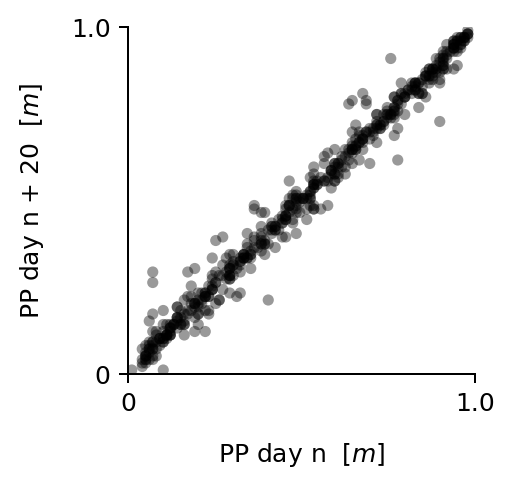

In [9]:
def fig_3c(preferences, final_day=20):
    """ run with data from baseline condition """
    fig, ax = plt.subplots(figsize=(2.5, 2.5), dpi=180)
    ax.scatter(preferences[:, 0], preferences[:, final_day], s=20, alpha=0.4, fc='k', ec='None')
    ax.set_ylabel(r'PP day n + ' + str(final_day) + '  $[m]$')
    ax.set_xlabel(r'PP day n  $[m]$')
    ax.set_xticks([0, L]); ax.set_yticks([0, L])
    ax.set_xticklabels(['0', str(L)]); ax.set_yticklabels(['0', str(L)])
    ax.set_aspect('equal')
    fig.show()

fig_3c(preferences)

## Fig. 3g

0.5 0.0010020040080159776


C:\Users\sctcl\AppData\Local\Temp\ipykernel_20396\3187138423.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


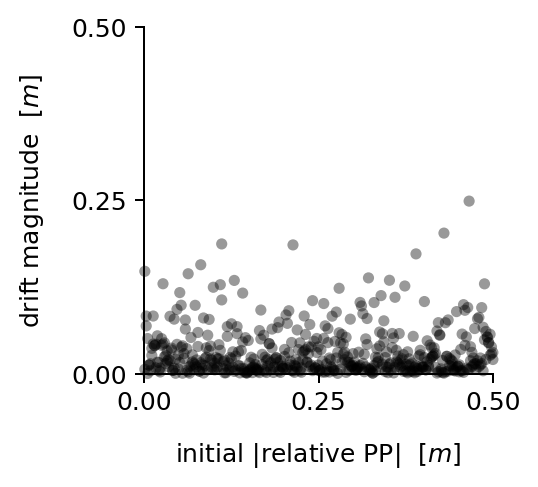

In [18]:
initial_distances = np.abs(initial_preferences - x_stim) # This should be half L, as its just the starting distance from deprevation stim
final_distances = np.abs(final_preferences - x_stim)
change = initial_distances - final_distances
total_drift = linear_distance(initial_preferences, final_preferences)
#print(initial_preferences.shape), print(initial_preferences)
print(max(initial_distances), min(initial_distances))
def fig_3g(initial_distances, total_drift):
    """ run with data from deprivation condition """
    fig, ax = plt.subplots(figsize=(2.5, 2.5), dpi=180)
    ax.scatter(initial_distances, total_drift, s=20, color='k', ec='None', clip_on=False, alpha=0.4)
    ax.set_yticks([0, L/4, L/2]); ax.set_xticks([0, L/4, L/2])
    ax.set_xlim(0, L/2); ax.set_ylim(0, L/2)
    ax.set_xlabel(r'initial |relative PP|  $[m]$')
    ax.set_ylabel(r'drift magnitude  $[m]$')
    fig.show()

fig_3g(initial_distances, total_drift)

## Supp. Fig. 3g

C:\Users\sctcl\AppData\Local\Temp\ipykernel_20396\248376626.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


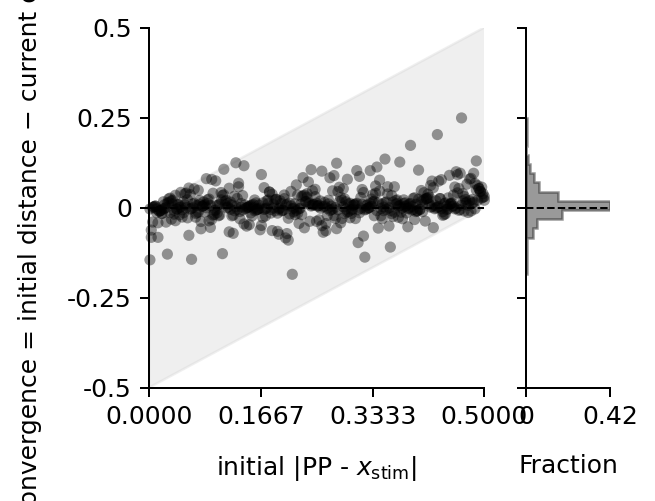

In [34]:
def supp_fig_3g_pos(initial_distances, change, L=1.0, bins=17):
    """
    Plot convergence in position space.

    Parameters
    ----------
    initial_distances : array-like
        For each neuron: initial |PP - x_stim| in the SAME UNITS as L (e.g., meters or normalized 0..L).
    change : array-like
        For each neuron: (initial |PP - x_stim|) - (current |PP - x_stim|).
        Positive values = convergence toward x_stim; negative = divergence.
    L : float
        Track length (x in [0, L]).
    bins : int
        Number of bins for the side histogram.
    """
    initial_distances = np.asarray(initial_distances, dtype=float)
    change = np.asarray(change, dtype=float)
    n = len(change)

    fig = plt.figure(figsize=(3.2, 2.5), dpi=180)
    gs = fig.add_gridspec(
        1, 2, width_ratios=(4, 1),
        left=0.1, right=0.9, bottom=0.1, top=0.9,
        wspace=0.2, hspace=0.05
    )
    ax = fig.add_subplot(gs[0])
    ax_hist = fig.add_subplot(gs[1], sharey=ax)

    # Feasible region in linear space: |change| <= initial_distance
    xs = np.linspace(0.0, L, 256)
    ax.fill_between(xs, xs, xs-L/2, color='lightgray', alpha=0.35)

    # Zero line for change
    ax.axhline(0, ls='--', color='k', lw=0.8)
    ax_hist.axhline(0, ls='--', color='k', lw=0.8)

    # Scatter of per-neuron convergence
    ax.scatter(initial_distances, change, s=20, color='k', ec='None', alpha=0.4, clip_on=False)

    # Side histogram as FRACTION of neurons
    weights = np.ones_like(change, dtype=float) / max(n, 1)
    ax_hist.hist(change, bins=bins, orientation="horizontal",
                 histtype="stepfilled", alpha=0.4, ec='k', fc='k',
                 weights=weights)

    # Axis limits and ticks
    ax.set_xlim(0, L/2)
    ax.set_ylim(-L/2, L/2)

    # Nice ticks: 0, L/3, 2L/3, L
    xticks = np.linspace(0, L/2, 4)
    yticks = np.linspace(-L/2, L/2, 5)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)
    ax.set_yticklabels([f"{y:.2g}" for y in yticks])

    # Histogram x ticks: 0 and max fraction shown
    xlim_hist_max = ax_hist.get_xlim()[1]
    ax_hist.set_xticks([0, xlim_hist_max])
    ax_hist.set_xticklabels([f"0", f"{xlim_hist_max:.2f}"])
    ax_hist.set_xlabel('Fraction')       # fraction of neurons in each bin
    ax_hist.tick_params(axis="y", labelleft=False)

    # Labels (linear space, no degrees)
    ax.set_xlabel(r'initial $|$PP - $x_{\mathrm{stim}}|$')
    ax.set_ylabel('convergence = initial distance − current distance')

    plt.tight_layout()
    plt.show()
    
supp_fig_3g_pos(initial_distances, change, L=L, bins=17)


### 3f

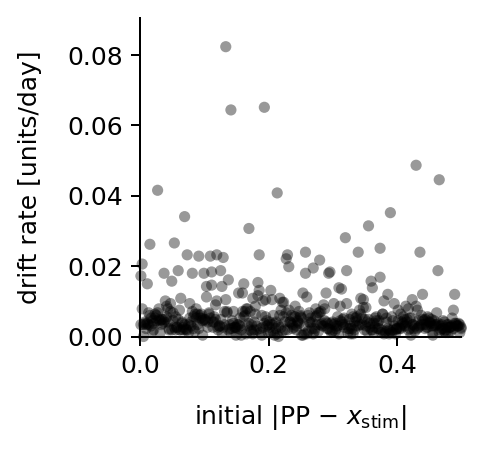

In [36]:
drift_rates = np.mean(
    np.array([np.abs(preferences[:, d+1] - preferences[:, d]) for d in range(n_days-1)]),
    axis=0
)

def supp_fig_3f_pos(initial_distances, drift_rates, L=1.0):
    fig, ax = plt.subplots(figsize=(2.3, 2.3), dpi=180)
    ax.scatter(initial_distances, drift_rates, s=20, color='k', ec='None', alpha=0.4, clip_on=False)
    ax.set_xlim(0, L/2)
    # y-limit: something sensible for your data (≤ L); auto works too:
    ax.set_ylim(0, min(L, max(1e-9, np.nanmax(drift_rates)*1.1)))
    ax.set_xlabel(r'initial $|$PP $-$ $x_{\mathrm{stim}}|$')
    ax.set_ylabel('drift rate [units/day]')
    plt.show()
supp_fig_3f_pos(initial_distances, drift_rates, L=L)

### 3d

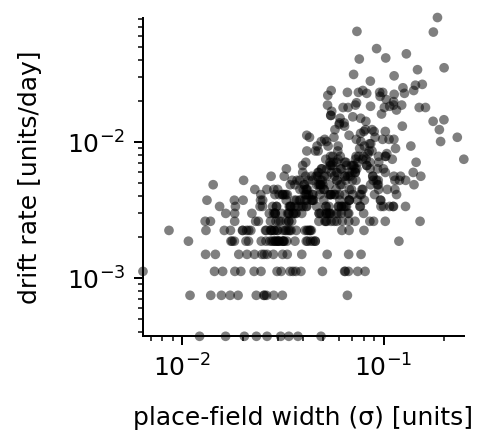

In [37]:
def supp_fig_3d_pos(sigmas, drift_rates):
    fig, ax = plt.subplots(figsize=(2.3, 2.3), dpi=180)
    ax.scatter(sigmas, drift_rates, s=15, color='k', ec='None', alpha=0.5, clip_on=False)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('place-field width (σ) [units]')
    ax.set_ylabel('drift rate [units/day]')
    plt.show()
supp_fig_3d_pos(vars, drift_rates)

### 3e

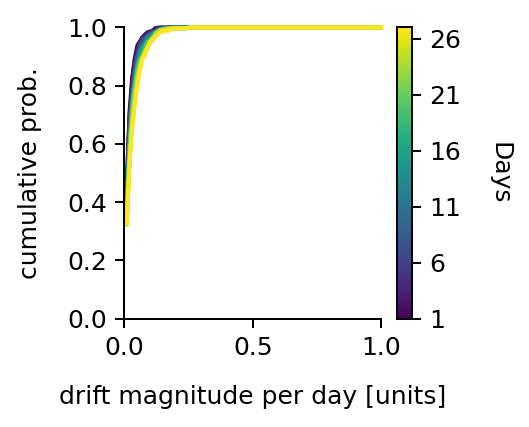

In [38]:
def supp_fig_3e_pos(absolute_change, n_days, L=1.0, bins=100):
    """
    absolute_change[d] = |PP_day(d+1) - PP_day(d)| for all neurons (array per day)
    """
    fig, ax = plt.subplots(figsize=(2.3, 2.1), dpi=180)

    cmap = plt.get_cmap('viridis')
    colors = [cmap(i) for i in np.linspace(0, 1, n_days-1)]

    for d in range(n_days-1):
        counts, edges = np.histogram(absolute_change[d], bins=bins, range=(0, L))
        pdf = counts / max(1, counts.sum())
        cdf = np.cumsum(pdf)
        ax.plot(edges[1:], cdf, c=colors[d], label=f'Day {d+1}', clip_on=False)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=1, vmax=n_days-1))
    cbar = plt.colorbar(sm, ax=ax, ticks=np.arange(1, n_days, 5))
    cbar.set_label('Days', rotation=270, labelpad=20, fontsize=10)

    ax.set_xlim(0, L)
    ax.set_ylim(0, 1)
    ax.set_xlabel('drift magnitude per day [units]')
    ax.set_ylabel('cumulative prob.')
    plt.show()
supp_fig_3e_pos(absolute_change, n_days, L=L, bins=100)

3i

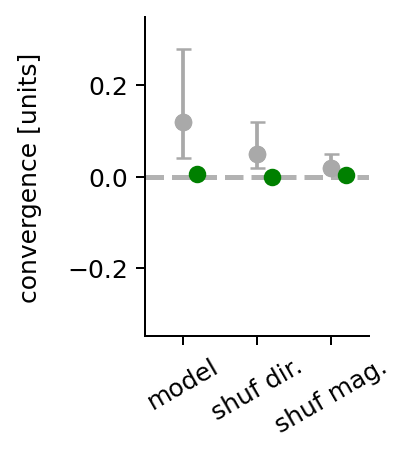

In [39]:
# Preferences over days (N x n_days)
PP = preferences.copy()
PP[:, 0] = np.linspace(0, L, N)           # define day-0 ordering if that’s your convention

# Changes relative to day 0 (signed & absolute)
dPP = [PP[:, d] - PP[:, 0] for d in range(n_days)]                    # signed change from day 0
rPP = [PP[:, d] - x_stim for d in range(n_days)]                      # signed relative to x_stim

# Shuffle magnitude / direction controls (preserve zeros)
dPP_ShM = [np.random.permutation(np.abs(d)) * (np.sign(d) + (d == 0)) for d in dPP]
dPP_ShD = [np.random.permutation(np.sign(d) + (d == 0)) * np.abs(d)   for d in dPP]

# Final (shuffled) preferences
PP_ShM = PP[:, 0][:, None] + np.column_stack(dPP_ShM)
PP_ShD = PP[:, 0][:, None] + np.column_stack(dPP_ShD)

# Relative to x_stim after shuffles
rPP_ShM = [PP_ShM[:, d] - x_stim for d in range(n_days)]
rPP_ShD = [PP_ShD[:, d] - x_stim for d in range(n_days)]

# Convergence (change in |relative distance to x_stim|)
drPP     = [np.abs(rPP[0])    - np.abs(r) for r in rPP]
drPP_ShM = [np.abs(rPP[0])    - np.abs(r) for r in rPP_ShM]
drPP_ShD = [np.abs(rPP[0])    - np.abs(r) for r in rPP_ShD]

def fig_3i_pos(drPP, drPP_ShM, drPP_ShD, data_means, data_lower, data_upper):
    fig, ax = plt.subplots(1, 1, figsize=(1.6, 2.3), dpi=180)
    # experimental reference (gray)
    ax.scatter([0, 1, 2], data_means, c='darkgrey', zorder=3)
    ax.errorbar([0, 1, 2], data_means, yerr=[data_lower, data_upper],
                fmt='o', c='darkgrey', capsize=3)
    # model medians (green)
    ax.scatter([0.2, 1.2, 2.2],
               [np.median(drPP[-1]), np.median(drPP_ShD[-1]), np.median(drPP_ShM[-1])],
               c='green', zorder=3)
    ax.set_xticks([0, 1, 2], ['model', 'shuf dir.', 'shuf mag.'], rotation=30)
    ax.set_ylabel('convergence [units]')
    ax.axhline(0, c='k', ls='--', alpha=0.3, lw=2)
    ax.set_xlim([-0.5, 2.5])
    # y-lims: auto based on your data
    ymin = min(np.min(drPP[-1]), np.min(drPP_ShD[-1]), np.min(drPP_ShM[-1]), 0) - 0.1
    ymax = max(np.max(drPP[-1]), np.max(drPP_ShD[-1]), np.max(drPP_ShM[-1]), 0) + 0.1
    ax.set_ylim(ymin, ymax)
    plt.show()
fig_3i_pos(drPP, drPP_ShM, drPP_ShD,
            data_means=[0.12, 0.05, 0.02],
            data_lower=[0.08, 0.03, 0.01],
            data_upper=[0.16, 0.07, 0.03])